# TP 2: Sequential stock data in higher dimension
## Numerical processing of financial data APM 50442 EP

Matthieu Garcin

# Import the data

We're going to work with a universe of stock of size greater than 10. It can be stocks from the same geographic area, for example a selection of stocks from S&P 500 index or CAC 40 index.

Example for French stocks (along with their identifier in yahoo finance) can be found in [Euronext website](https://live.euronext.com/en/product/indices/FR0003500008-XPAR#index-composition):


* Accor (AC.PA)
* Air liquide (AI.PA)
* Airbus (AIR.PA)
* Bouygues (EN.PA)
* Crédit agricole (ACA.PA)
* Danone (BN.PA)
* Engie (ENGI.PA)
* LVMH (MC.PA)
* Michelin (ML.PA)
* Orange (ORA.PA)
* Société générale (GLE.PA)
* Thales (HO.PA)
* BNP Paribas (BNP.PA)
* ...

We import first the prices, like in TP 1.

## Prices with yfinance

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

# Import the yfinance package
#(the first two following lines are to be executed if the current version does not contain "adjusted close"; it may require to restart the session if working in Google Colab)
%pip uninstall yfinance -y --quiet
%pip install yfinance==0.2.50 --quiet
import yfinance as yf
print(yf.__version__)

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
0.2.50


In [2]:
start_date = '2005-01-01'
end_date = '2024-12-31'
tickers_list = ['AI.PA', 'AIR.PA', 'EN.PA', 'ACA.PA', 'BN.PA', 'ENGI.PA', 'MC.PA', 'ML.PA', 'ORA.PA', 'GLE.PA', 'HO.PA', 'BNP.PA']

data_stocks = yf.download(tickers=tickers_list, start=start_date, end=end_date)
print("data_stocks shape: ", data_stocks.shape)
data_stocks.head()

Failed to get ticker 'ENGI.PA' reason: Expecting value: line 1 column 1 (char 0)
[                       0%                       ]Failed to get ticker 'ML.PA' reason: Expecting value: line 1 column 1 (char 0)
[********              17%                       ]  2 of 12 completedFailed to get ticker 'HO.PA' reason: Expecting value: line 1 column 1 (char 0)
[************          25%                       ]  3 of 12 completedFailed to get ticker 'ORA.PA' reason: Expecting value: line 1 column 1 (char 0)
Failed to get ticker 'BNP.PA' reason: Expecting value: line 1 column 1 (char 0)
[****************      33%                       ]  4 of 12 completedFailed to get ticker 'ACA.PA' reason: Expecting value: line 1 column 1 (char 0)
Failed to get ticker 'MC.PA' reason: Expecting value: line 1 column 1 (char 0)
[**********************50%                       ]  6 of 12 completedFailed to get ticker 'BN.PA' reason: Expecting value: line 1 column 1 (char 0)
[**********************58%***        

data_stocks shape:  (0, 72)


Empty DataFrame
Columns: [(Adj Close, ACA.PA), (Adj Close, AI.PA), (Adj Close, AIR.PA), (Adj Close, BN.PA), (Adj Close, BNP.PA), (Adj Close, EN.PA), (Adj Close, ENGI.PA), (Adj Close, GLE.PA), (Adj Close, HO.PA), (Adj Close, MC.PA), (Adj Close, ML.PA), (Adj Close, ORA.PA), (Close, ACA.PA), (Close, AI.PA), (Close, AIR.PA), (Close, BN.PA), (Close, BNP.PA), (Close, EN.PA), (Close, ENGI.PA), (Close, GLE.PA), (Close, HO.PA), (Close, MC.PA), (Close, ML.PA), (Close, ORA.PA), (High, ACA.PA), (High, AI.PA), (High, AIR.PA), (High, BN.PA), (High, BNP.PA), (High, EN.PA), (High, ENGI.PA), (High, GLE.PA), (High, HO.PA), (High, MC.PA), (High, ML.PA), (High, ORA.PA), (Low, ACA.PA), (Low, AI.PA), (Low, AIR.PA), (Low, BN.PA), (Low, BNP.PA), (Low, EN.PA), (Low, ENGI.PA), (Low, GLE.PA), (Low, HO.PA), (Low, MC.PA), (Low, ML.PA), (Low, ORA.PA), (Open, ACA.PA), (Open, AI.PA), (Open, AIR.PA), (Open, BN.PA), (Open, BNP.PA), (Open, EN.PA), (Open, ENGI.PA), (Open, GLE.PA), (Open, HO.PA), (Open, MC.PA), (Open, ML.PA), (Open, ORA.PA), (Volume, ACA.PA), (Volume, AI.PA), (Volume, AIR.PA), (Volume, BN.PA), (Volume, BNP.PA), (Volume, EN.PA), (Volume, ENGI.PA), (Volume, GLE.PA), (Volume, HO.PA), (Volume, MC.PA), (Volume, ML.PA), (Volume, ORA.PA)]
Index: []

[0 rows x 72 columns]

Let's display the price (adjusted close) of all the stocks.

In [ ]:
for ticker in data_stocks['Adj Close'].columns:
    plt.plot(data_stocks['Adj Close'].index, data_stocks['Adj Close'][ticker], label=ticker)
plt.title("Time series of prices of our selected stocks")
plt.ylabel("stock value")
plt.grid(False)
plt.legend()
plt.show()

## Prices with Stooq

If an error occurs with yfinance...

But impossible to download French stocks. So, let's work with:
* Nvidia (NVDA)
* Apple (AAPL)
* Microsoft (MSFT)
* Amazon (AMZN)
* Alphabet (GOOGL)
* Meta (META)
* Tesla (TSLA)
* Walmart (WMT)

In [3]:
import pandas_datareader.data as web
import pandas as pd

start_date = '2005-01-01'
end_date = '2024-12-31'
tickers_list = ['NVDA','AAPL','MSFT','AMZN','GOOGL','META','TSLA','WMT']
columns_needed = ['Open', 'High', 'Low', 'Close', 'Volume']

data_by_coltype = {col: [] for col in columns_needed}

for ticker in tickers_list:
    try:
        df = web.DataReader(ticker, 'stooq')
        df = df.sort_index()  # sort the dates

        # Rename "Close" in "Adj Close"
        df = df.rename(columns={'Close': 'Adj Close'})
        df['Ticker'] = ticker

        for col in columns_needed:
            col_name = 'Adj Close' if col == 'Close' else col
            series = df[[col_name]].copy()
            series.columns = [ticker]
            data_by_coltype[col].append(series)
    except Exception as e:
        print(f"Erreur pour {ticker}: {e}")

# Concatenate and create MultiIndex
final_dfs = []
for col in columns_needed:
    dfs = data_by_coltype[col]
    if dfs:
        col_df = pd.concat(dfs, axis=1)
        col_df.columns = pd.MultiIndex.from_product([[col if col != 'Close' else 'Adj Close'], col_df.columns])
        final_dfs.append(col_df)

data_stocks = pd.concat(final_dfs, axis=1)

print(data_stocks.head())

               Open                                                         \
               NVDA     AAPL     MSFT     AMZN    GOOGL      META     TSLA   
Date                                                                         
2021-01-25  13.7477  139.753  221.456  166.425  95.2916  278.1400  285.000   
2021-01-26  13.5468  140.276  224.131  164.818  93.9589  278.1398  297.127   
2021-01-27  13.1973  140.108  230.051  167.074  93.4068  282.5300  290.117   
2021-01-28  12.9637  136.275  227.745  161.752  91.2193  277.1800  273.333   
2021-01-29  13.0425  132.677  228.117  161.500  91.3698  265.3000  276.667   

                        High           ... Adj Close              Volume  \
                WMT     NVDA     AAPL  ...      TSLA      WMT       NVDA   
Date                                   ...                                 
2021-01-25  46.2490  13.7946  141.714  ...   293.600  46.5197  251748494   
2021-01-26  46.3337  13.6108  140.946  ...   294.363  46.9393  16439658

#Correlation (Q1)

**Question 1:** Calculate the covariance matrix of daily price returns of all the stocks.

* **1.a/** Create a dataframe containing the series of all the price returns.

                NVDA      AAPL      MSFT      AMZN     GOOGL      META  \
Date                                                                     
2021-01-25  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
2021-01-26 -0.016050  0.001698  0.012283  0.009751  0.007217  0.014532   
2021-01-27 -0.038527 -0.007766  0.002387 -0.028123 -0.046653 -0.035136   
2021-01-28  0.010307 -0.034860  0.025956  0.001559  0.018836 -0.026236   
2021-01-29 -0.004678 -0.037530 -0.029135 -0.009705 -0.013942 -0.025170   

                TSLA       WMT  
Date                            
2021-01-25  0.000000  0.000000  
2021-01-26  0.002599  0.009020  
2021-01-27 -0.021436 -0.024968  
2021-01-28 -0.033244 -0.000655  
2021-01-29 -0.050155 -0.022636  


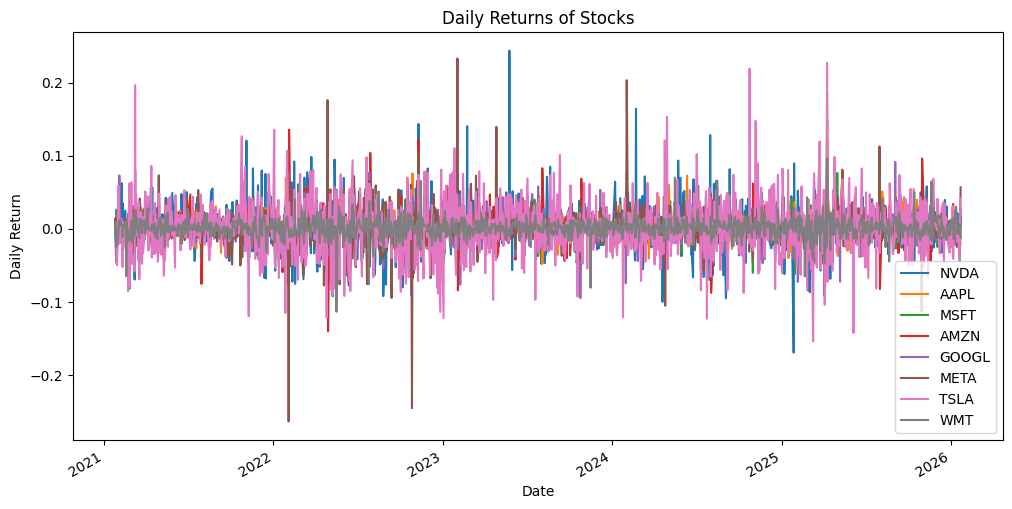

In [4]:
import pandas as pd

dates = data_stocks.index
returns_df = pd.DataFrame(index=dates)

#We fill this new data frame
for ticker in tickers_list:
    adj_close_prices = data_stocks[('Adj Close', ticker)]
    returns = adj_close_prices.pct_change().fillna(0)
    returns_df[ticker] = returns

print(returns_df.head())

# Graph the data frame
returns_df.plot(figsize=(12, 6))
plt.title("Daily Returns of Stocks")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.show()

ACA.PA seems to have some price returns lower than 100%. Check the price series and remove this asset (or skip if no problem with your dataset).

In [ ]:
# # We plot this series alone to check the problem


# # We remove the series from the dataframe
# returns_df = ...
# print(returns_df.head())

# # We display the cleaned graph of price returns
# ...

* **1.b/** Create the covariance and correlation matrices and display the correlation matrix in a heatmap.

In [ ]:
# Covariance
cov_matrix = returns_df.cov()
print(cov_matrix)

# Correlation
correlation_matrix = returns_df.corr()
print(correlation_matrix)

           NVDA      AAPL      MSFT      AMZN     GOOGL      META      TSLA  \
NVDA   0.001076  0.000297  0.000332  0.000403  0.000339  0.000447  0.000590   
AAPL   0.000297  0.000304  0.000177  0.000214  0.000196  0.000231  0.000333   
MSFT   0.000332  0.000177  0.000261  0.000234  0.000201  0.000260  0.000260   
AMZN   0.000403  0.000214  0.000234  0.000489  0.000266  0.000363  0.000379   
GOOGL  0.000339  0.000196  0.000201  0.000266  0.000382  0.000299  0.000310   
META   0.000447  0.000231  0.000260  0.000363  0.000299  0.000747  0.000365   
TSLA   0.000590  0.000333  0.000260  0.000379  0.000310  0.000365  0.001450   
WMT    0.000054  0.000067  0.000052  0.000071  0.000051  0.000069  0.000089   

            WMT  
NVDA   0.000054  
AAPL   0.000067  
MSFT   0.000052  
AMZN   0.000071  
GOOGL  0.000051  
META   0.000069  
TSLA   0.000089  
WMT    0.000174  
           NVDA      AAPL      MSFT      AMZN     GOOGL      META      TSLA  \
NVDA   1.000000  0.518888  0.626953  0.555282  

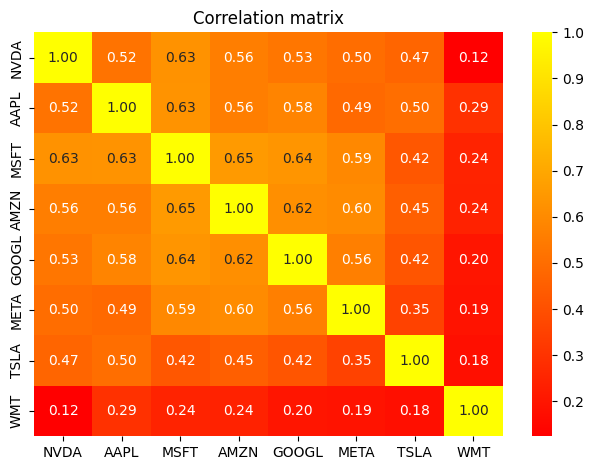

In [ ]:
import seaborn as sns

# Display the heatmap
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="autumn")
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

* **1.c/** Define a function calculating the average correlation in your selection of assets (don't consider the diagonal terms in the correlation) and display the time-evolution of this function, for correlations calculated in 1-year windows.

We start by defining the function calculating the mean of the correlations.

In [12]:
def mean_correl(matrix):
    """
    This function calculates the average of the off-diagonal terms
    of a symmetric matrix
    """
    return (np.sum(matrix.values) - np.trace(matrix.values)) / (matrix.shape[0] * (matrix.shape[0] - 1))

Then we calculate dynamically this quantity.

            Mean Correlation
Date                        
2022-01-21          0.435696
2022-01-24          0.435172
2022-01-25          0.439955
2022-01-26          0.434968
2022-01-27          0.436714
...                      ...
2026-01-15          0.458118
2026-01-16          0.455188
2026-01-20          0.457577
2026-01-21          0.455824
2026-01-22          0.455940

[1004 rows x 1 columns]


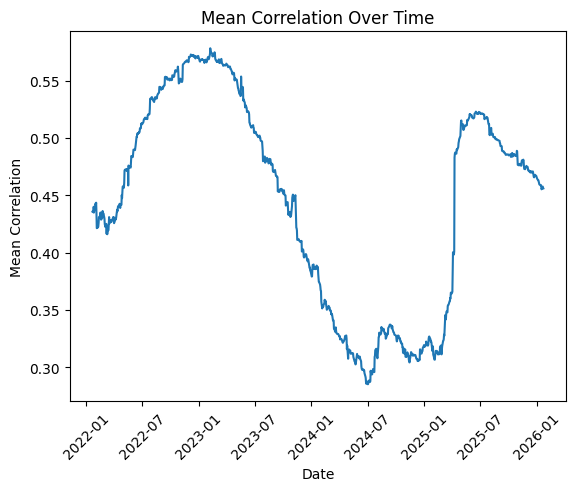

In [15]:
# We calculate dynamically a correlation matrix

window_size = 252
mean_correl_series = []

# Apply a sliding window to determine the correlation matrix in each period
for start_idx in range(len(returns_df) - window_size + 1):
    end_idx = start_idx + window_size
    window_data = returns_df.iloc[start_idx:end_idx]
    corr_matrix = window_data.corr()
    mean_corr = mean_correl(corr_matrix)
    mean_correl_series.append(mean_corr)

# Store the results in a new data frame
stats_df = pd.DataFrame(mean_correl_series, columns=['Mean Correlation'])
stats_df.index = returns_df.index[window_size-1:]

print(stats_df)
plt.plot(stats_df)
plt.xlabel("Date")
plt.xticks(rotation=45)
plt.ylabel("Mean Correlation")
plt.title("Mean Correlation Over Time")
plt.show()

When is this average correlation high?

* **1.d/** Compare this series of average correlation with the series of average volatility. Are these two quantities correlated?

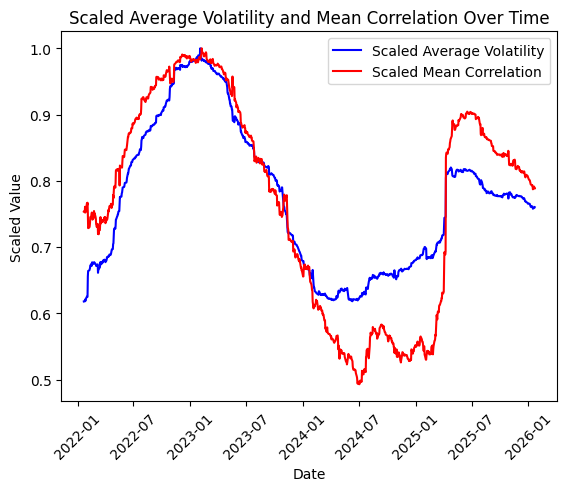

In [25]:
# We calculate dynamically a volatility vector
window_size = 252
volatility_series = []

for start_idx in range(len(returns_df) - window_size + 1):
    end_idx = start_idx + window_size
    window_data = returns_df.iloc[start_idx:end_idx]
    volatilities = window_data.std()
    avg_volatility = volatilities.mean()
    volatility_series.append(avg_volatility)


volatility_df = pd.DataFrame(volatility_series, columns=['Average Volatility'])
volatility_df.index = returns_df.index[window_size-1:]

plt.plot(volatility_df / volatility_df.max(), color='b', label='Scaled Average Volatility')
plt.plot(stats_df / stats_df.max(), color='r', label='Scaled Mean Correlation')
plt.xlabel("Date")
plt.xticks(rotation=45)
plt.ylabel("Scaled Value")
plt.title("Scaled Average Volatility and Mean Correlation Over Time")
plt.legend()
plt.show()

In [18]:
# Correlation between average correlation in the market and average volatility
print(np.corrcoef(stats_df['Mean Correlation'], volatility_df['Average Volatility'])[0, 1])

0.9153334697117042


* **1.e/** Now determine the beta of each of the assets, assuming the market is at all time an equally-weighted average of all the stocks selected in this work. Start with a constant beta and then display a time-varying beta, using sliding windows.

In [19]:
# Calculate the price return of the market
returns_df['market'] = returns_df.mean(axis=1)
print(returns_df.head())

                NVDA      AAPL      MSFT      AMZN     GOOGL      META  \
Date                                                                     
2021-01-25  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
2021-01-26 -0.016050  0.001698  0.012283  0.009751  0.007217  0.014532   
2021-01-27 -0.038527 -0.007766  0.002387 -0.028123 -0.046653 -0.035136   
2021-01-28  0.010307 -0.034860  0.025956  0.001559  0.018836 -0.026236   
2021-01-29 -0.004678 -0.037530 -0.029135 -0.009705 -0.013942 -0.025170   

                TSLA       WMT    market  
Date                                      
2021-01-25  0.000000  0.000000  0.000000  
2021-01-26  0.002599  0.009020  0.005131  
2021-01-27 -0.021436 -0.024968 -0.025028  
2021-01-28 -0.033244 -0.000655 -0.004792  
2021-01-29 -0.050155 -0.022636 -0.024119  


We now calculate a vector of constant beta for all the assets.

In [ ]:
# Calculate the beta between each stock and the market
beta_list = []
...

# Put the result in a dataframe in which the index is the stock name
beta_df = ...
print(beta_df)

#Check hat the average beta is one
mean_beta = ...
print("Average beta: ", mean_beta)

Let's display the graph of a time-varying beta.

In [ ]:
#Put in a dataframe time-varying correlations
...

#Put in another dataframe time-varying volatilities
...

#Get the dataframe of time-varying betas
...

#Display the graph
...

# Lead-Lag relationship (Q2)

**Question 2:** Estimate a lead-lag relationship between a selection of stocks.

* **2.a/** Write a cross-correlation function, which depends on two stock names and a lag.

In [ ]:
def cross_correl(df, stock1, stock2, lag):
    ...

    return ...

#Example of application
asset1="GLE.PA"
asset2="BNP.PA"
lag=1
print("cross-correlation of stocks", asset1,"and", asset2, "with a lag", lag, ":", cross_correl(returns_df,asset1,asset2,lag))


* **2.b/** Display the cross-correlation function for all the pairs of stocks studied in this work. Do you find any lead-lag relationship?

In [ ]:
max_lag=10
#create a dataframe to gather all the correlations
cross_correl_df = ...

#Fill this dataframe calling the cross_correl function
...
            cross_correl_df[f'{ticker1} vs {ticker2}'] = crosscorrelations

print(cross_correl_df)

plt.plot(cross_correl_df, label=cross_correl_df.columns)
plt.title("cross-correlation functions")
plt.xlabel('Lag (days)')
plt.ylabel('Correlation')
plt.legend(bbox_to_anchor=(1, 1), ncol=3)
plt.grid(True)
plt.show()

In [ ]:
#Create a dataframe with all the pairs as index
pairs_df = ...

# Find the pair with the biggest absolute cross-correlation for a lag of -1 or a lag of 1.
...
print(f'The pair with the highest absolute correl with lag -1 is {best_pair1}, with correlation {max_corr}')

...
print(f'The pair with the highest absolute correl with lag 1 is {best_pair2}, with correlation {max_corr}')

# Find the pair with the biggest asymmetry in the correlation function (biggest difference between absolute correls of lags -1 and 1).
...
print(f'Biggest asymmetry for the pair {best_pair3}, with correlations of lags -1 and 1 equal to {lag_corr[best_pair3]} and {lead_corr[best_pair3]}')

#We print the dataframe and plot the best pairs
print(pairs_df)
plt.plot(cross_correl_df.index, cross_correl_df[best_pair1], label=best_pair1)
plt.plot(cross_correl_df.index, cross_correl_df[best_pair2], label=best_pair2)
plt.plot(cross_correl_df.index, cross_correl_df[best_pair3], label=best_pair3)
plt.xlabel('Lag (days)')
plt.ylabel('Correl')
plt.legend()
plt.grid()
plt.show()

* **2.c/** For the selected pair, display the cross-correlation function for high-frequency data (import files from TP1). Do you observe a lead-lag effect on returns or on absolute returns?

In [ ]:
#Import the data
import pandas as pd
data_AI = pd.read_excel('/content/AI_Prices.xlsx', engine='openpyxl', header=1)
data_AI['price_AI'] = (data_AI['High']+data_AI['Low'])/2
data_AI_price = data_AI[['price_AI']] #we create a new dataframe
data_GLE = pd.read_excel('/content/GLE_Prices.xlsx', engine='openpyxl', header=1)
data_GLE['price_GLE'] = (data_GLE['High']+data_GLE['Low'])/2
data_GLE_price = data_GLE[['price_GLE']] #we create a new dataframe

#Merge the two dataframes, focusing on dates in common
data_merged = pd.merge(...)
print(data_merged.head)

In [ ]:
#Add returns in the dataframe
data_merged['return_AI'] = ...
data_merged['return_GLE'] = ...
data_merged['return_AI_abs'] = ...
data_merged['return_GLE_abs'] = ...
print(data_merged.head)

#Display the cross-correlation function.
max_lag=100
cross_correl_merged_df = ...

...
cross_correl_merged_df['AI vs GLE'] = ...

...
cross_correl_merged_df['AI_abs vs GLE_abs'] = ...

print(cross_correl_merged_df)

plt.plot(cross_correl_merged_df, label = cross_correl_merged_df.columns)
plt.title("cross-correlation function: AI vs GLE")
plt.xlabel('Lag (minutes)')
plt.ylabel('Correlation')
plt.legend()
plt.grid(True)
plt.show()

*Questions 2.d, 2.e and 2.f are more difficult: they are optional and will not be corrected.*

* **2.d/** ($\star$) For the selected pair (and the most relevant between returns and absolute returns), estimate a parsimonious lag model. Display the resulting function.

* **2.e/** ($\star$) Split your dataset in two equal periods. For a pair of assets, estimate the lag function in each period. Are they equal? Using the lag function of the first period, make forecasts in the second period. Is it performing?

* **2.f/** ($\star$) Do the same kind of forecast but reestimating each time the model in a small window just before the forecasting date.

# Multiresolution correlation (Q3)

**Question 3:** Implement the multiresolution correlation and find multiscale stylized facts.

* **3.a/** Write a function returning the multiscale correlation between two stocks for a given range of resolutions. You can use the pair selected in the previous question, considering the high-frequency sampling.

In [ ]:
def correl_resolution(df, stock1, stock2, resolution_abs):
    #We create a new dataframe, adding a column giving a new index
    #to group returns by groups of 2^j consecutive ones, without overlap
    #where j is the resolution
    ...

    #Average by group
    ...

    #Calculate correlation
    ...

    return ...

print(correl_resolution(data_merged,'return_GLE','return_AI',6))

* **3.b/** Display the multiresolution correlation for your pairs of stocks. Do you detect Epps effect?

In [ ]:
resolution_max=10
multires_correl_df = ...
multires_correl_df['returns'] = ...
multires_correl_df['returns_abs'] = ...

print(multires_correl_df)
plt.plot(multires_correl_df,label = multires_correl_df.columns)
plt.grid()
plt.xlabel('Resolution')
plt.ylabel('Correlation')
plt.legend()

*Question 3.c is more difficult: it is optional and will not be corrected.*

* **3.c/** ($\star$) For the pair of stocks with the strongest lead-lag effect found in question 2, make the same lead-lag analysis in a multiresolution perspective. Does the result remain the same across scales?